# Group-Level comparison of Epoch-Based Decoding Performance

This script aggregates  decoding curves of P300 workflow variants.




In [1]:
import os
from os.path import join
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
def load_decoding_results(npz_path):
    with np.load(npz_path) as data:
        epoch_bins_loaded = data['epoch_bins']
        mean_acc = data['mean_accuracies']
        se_acc = data['se_accuracies']
    return epoch_bins_loaded, mean_acc, se_acc


In [3]:
manuscript_dir = r'C:\Users\Radovan\OneDrive\Radboud\Studentships\Jordy Thielen\Manuscript'
m_ica_dir = join(manuscript_dir, 'data', 'decoding', 'ica')
m_noica_dir = join(manuscript_dir, 'data', 'decoding','noica')
fig_dir = join(manuscript_dir, 'figures')

epoch_bins = np.linspace(5, 80, 16, dtype=int)
task = 'covert'


# Full paths
# Data1 => with rejections
# Data2 => without rejections
data1_path = os.path.join(m_ica_dir, f"{task}_lda_p300_decC_64_ica.npz")
data2_path = os.path.join(m_noica_dir, f"{task}_lda_p300_decC_64_noica.npz" )
data3_path = os.path.join(m_ica_dir, f"{task}_lda_alphaCSP_decC_64_ica.npz")
data4_path = os.path.join(m_noica_dir, f"{task}_lda_alphaCSP_decC_64_noica.npz" )
data5_path = os.path.join(m_ica_dir, f"{task}_lda_cvep_decC_64_ica.npz" )
data6_path = os.path.join(m_noica_dir, f"{task}_lda_cvep_decC_64_noica.npz" )
data7_path = os.path.join(m_ica_dir, f"{task}_lda_alphaSUBSET_decC_64_nativespace.npz")
data8_path = os.path.join(m_noica_dir, f"{task}_lda_alphaSUBSET_decC_64_noica.npz" )

# --...---...---...---...---...---...---...---...---...---...---...---...---...-
epoch_bins1, mean_acc1, se_acc1 = load_decoding_results(data1_path)
epoch_bins2, mean_acc2, se_acc2 = load_decoding_results(data2_path)
epoch_bins3, mean_acc3, se_acc3 = load_decoding_results(data3_path)
epoch_bins4, mean_acc4, se_acc4 = load_decoding_results(data4_path)
epoch_bins5, mean_acc5, se_acc5 = load_decoding_results(data5_path)
epoch_bins6, mean_acc6, se_acc6 = load_decoding_results(data6_path)
epoch_bins7, mean_acc7, se_acc7 = load_decoding_results(data7_path)
epoch_bins8, mean_acc8, se_acc8 = load_decoding_results(data8_path)
# --...---...---...---...---...---...---...---...---...---...---...---...---...-
data = {
    'P300 w/ ICA': {
        'mean': mean_acc1,
        'se': se_acc1,
        'color': 'tab:blue',
        'marker': 'o',
        'linestyle': '-'
    },
    'P300 wo/ ICA': {
        'mean': mean_acc2,
        'se': se_acc2,
        'color': 'tab:blue',
        'marker': 'o',
        'linestyle': '--'
    },
    'Alpha csp w/ ICA': {
        'mean': mean_acc3,
        'se': se_acc3,
        'color': 'orange',
        'marker': 'o',
        'linestyle': '-'
    },
    'Alpha csp wo/ ICA': {
        'mean': mean_acc4,
        'se': se_acc4,
        'color': 'orange',
        'marker': 'o',
        'linestyle': '--'
        },
    'Alpha subset w/ ICA': {
        'mean': mean_acc7,
        'se': se_acc3,
        'color': 'tab:orange',
        'marker': 'x',
        'linestyle': '-'
    },
    'Alpha subset wo/ ICA': {
        'mean': mean_acc8,
        'se': se_acc4,
        'color': 'tab:orange',
        'marker': 'x',
        'linestyle': '--'

},
    'cVEP w/ ICA': {
        'mean': mean_acc5,
        'se': se_acc5,
        'color': 'tab:green',
        'marker': 'o',
        'linestyle': '-'
    },
    'cVEP wo/ ICA': {
        'mean': mean_acc6,
        'se': se_acc6,
        'color': 'tab:green',
        'marker': 'o',
        'linestyle': '--'

}
}

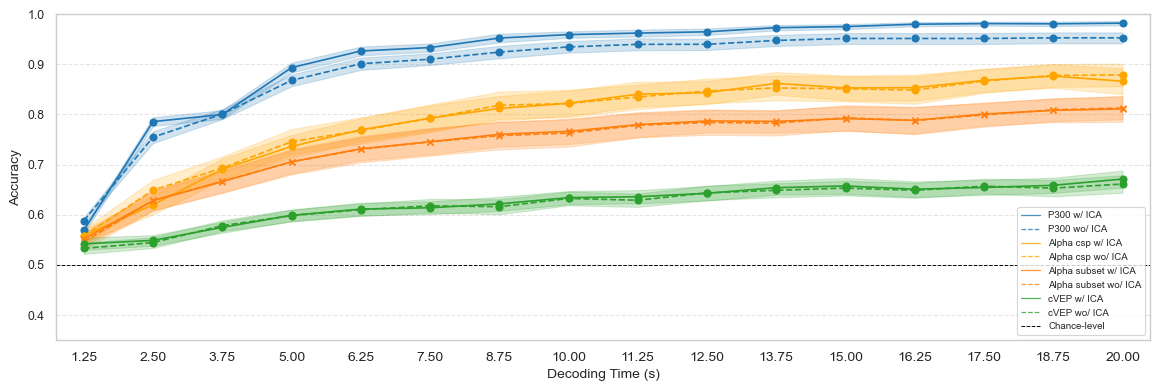

P300 w/ ICA: 0.98 ± 0.00
P300 wo/ ICA: 0.95 ± 0.01
Alpha csp w/ ICA: 0.87 ± 0.03
Alpha csp wo/ ICA: 0.88 ± 0.02
Alpha subset w/ ICA: 0.81 ± 0.03
Alpha subset wo/ ICA: 0.81 ± 0.02
cVEP w/ ICA: 0.67 ± 0.02
cVEP wo/ ICA: 0.66 ± 0.02


In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn style
sns.set_context('paper')
sns.set_style('whitegrid')

# Define ISI and convert epoch_bins to milliseconds
isi = 0.250  # inter-stimulus interval in ms
x_ms = np.array(epoch_bins) * isi

# Create the plot
fig, ax = plt.subplots(figsize=(11.69, 4))

# Plot each dataset with its mean ± SE band
for label, ds in data.items():
    ax.plot(x_ms, ds['mean'],
            marker=ds['marker'], linestyle=ds['linestyle'],
            color=ds['color'], label='')
    ax.fill_between(x_ms,
                    ds['mean'] - ds['se'],
                    ds['mean'] + ds['se'],
                    color=ds['color'], alpha=0.2)
    #  tiny horizontal marker at y = m
    m  = ds['mean'][-1]   # final mean
    se = ds['se'][-1]     # final SE
    col= ds['color']
    ls = ds['linestyle']
   
    ax.axhline(
        m,
        xmin=0, xmax=0.0,
        color=col,
        linestyle=ls,
        linewidth=0.9,
        alpha=0.8,
        label = f"{label}"
    )
# Chance level line
ax.axhline(0.5, color='k', linestyle='--', linewidth=0.7, label='Chance-level')

data_acc, data_sem = mean_acc1[-1], se_acc1[-1]


# Full-trial integration reference line (using the last dataset)
last_label = list(data)[-1]
full_mean = data[last_label]['mean'][-1]
full_se   = data[last_label]['se'][-1]


# Customize axes
ax.set_xlabel("Decoding Time (s)", fontsize=10)
ax.set_ylabel("Accuracy", fontsize=10)
ax.set_ylim(0.35, 1.0)
ax.set_xlim(x_ms.min()-0.5, x_ms.max()+0.5)
ax.set_xticks(x_ms)
ax.tick_params(axis='x', labelsize=10, )

# Grid and legend
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.xaxis.grid(False)
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='lower right', fontsize=7)

# Tight layout
plt.tight_layout()

# Save the figure
save_file = os.path.join(fig_dir, 'decoding_all.pdf')
os.makedirs(fig_dir, exist_ok=True)
# png_path = os.path.join(save_dir, f"{task}_lda_p300_decC_results_comparison.png")
# svg_path = os.path.join(save_dir, f"{task}_lda_p300_decC_results_comparison.svg")
# plt.savefig(png_path, dpi=300, bbox_inches='tight')
# plt.savefig(svg_path, dpi=300, bbox_inches='tight')
plt.savefig(save_file, format='pdf',
             dpi=300, bbox_inches='tight')  
plt.show()

# Print the final accuracies for each condition
for label in data.keys():
    m = data[label]['mean'][-1]
    s = data[label]['se'][-1]
    print(f"{label}: {m:.2f} ± {s:.2f}")


In [6]:
data

{'P300 w/ ICA': {'mean': array([0.56853448, 0.78577586, 0.8       , 0.89353448, 0.92672414,
         0.93362069, 0.95258621, 0.95948276, 0.9625    , 0.96508621,
         0.97327586, 0.97543103, 0.98017241, 0.98146552, 0.98103448,
         0.98232759]),
  'se': array([0.00614495, 0.0086792 , 0.00870647, 0.00978402, 0.00886977,
         0.00815791, 0.0086073 , 0.00641229, 0.0069769 , 0.00654773,
         0.00519836, 0.00500753, 0.00406716, 0.00416214, 0.00450511,
         0.00424595]),
  'color': 'tab:blue',
  'marker': 'o',
  'linestyle': '-'},
 'P300 wo/ ICA': {'mean': array([0.58793103, 0.75474138, 0.80086207, 0.86810345, 0.9012931 ,
         0.91034483, 0.92456897, 0.93491379, 0.94008621, 0.94008621,
         0.94784483, 0.95172414, 0.95172414, 0.95172414, 0.95301724,
         0.95301724]),
  'se': array([0.00637823, 0.01181088, 0.01005209, 0.01173469, 0.01231801,
         0.01151869, 0.01235021, 0.0114428 , 0.01188873, 0.01137767,
         0.01112485, 0.01091674, 0.01083131, 0.01091